<a href="https://colab.research.google.com/github/rezamarzban/electromagnetic/blob/main/meep/Dipole_Maxwell.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install Miniconda
!wget https://repo.anaconda.com/miniconda/Miniconda3-latest-Linux-x86_64.sh
!bash Miniconda3-latest-Linux-x86_64.sh -bfp /usr/local

# Install pymeep
!conda install -y -c conda-forge pymeep

--2024-02-05 03:39:38--  https://repo.anaconda.com/miniconda/Miniconda3-latest-Linux-x86_64.sh
Resolving repo.anaconda.com (repo.anaconda.com)... 104.16.130.3, 104.16.131.3, 2606:4700::6810:8203, ...
Connecting to repo.anaconda.com (repo.anaconda.com)|104.16.130.3|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 141613749 (135M) [application/octet-stream]
Saving to: ‘Miniconda3-latest-Linux-x86_64.sh’

Miniconda3-latest-L 100%[===================>] 135.05M   152MB/s    in 0.9s    

2024-02-05 03:39:39 (152 MB/s) - ‘Miniconda3-latest-Linux-x86_64.sh’ saved [141613749/141613749]

PREFIX=/usr/local
Unpacking payload ...
                                                                                     
Installing base environment...





Preparing transaction: - \ | / - \ | / - \ | / - \ | / - \ | done
Executing transaction: - \ | / - \ | / - \ | / - \ | / - \ | / - \ | / - \

In [2]:
%%writefile dipole_maxwell.py

import numpy as np
import meep as mp

import matplotlib

matplotlib.use("agg")
import matplotlib.pyplot as plt

sxy = 196
f = 0.01
area = mp.Vector3(sxy+4,sxy+4,0)

dip = [mp.Block(mp.Vector3(1, 24),
        center=mp.Vector3(0,12),
        material=mp.metal),

        mp.Block(mp.Vector3(1, 24),
        center=mp.Vector3(0,-12),
        material=mp.metal),

        mp.Block(mp.Vector3(1, 2),
        center=mp.Vector3(0, 0),
        material=mp.Medium( D_conductivity=0.05))
        ]

src = [mp.Source(mp.ContinuousSource(frequency=f),
        component=mp.Ey,
        center=mp.Vector3(0, 0,0)),
        ]

sim = mp.Simulation(cell_size=area, boundary_layers=[mp.PML(2.0)],
                    geometry=dip, sources=src, resolution=10)

sim.run(until=100)

plt.figure(dpi=150)
sim.plot2D()
plt.savefig("sim.png")
plt.show()

ey_data = sim.get_array(center=mp.Vector3(0, 0, 0), size=mp.Vector3(sxy, sxy, 0), component=mp.Ey)

radiated_power = np.sum((np.abs(ey_data) ** 2) / 2)

print("Radiated Power:", radiated_power)

Writing dipole_maxwell.py


In [3]:
!python dipole_maxwell.py

-----------
Initializing structure...
time for choose_chunkdivision = 0.00110388 s
Working in 2D dimensions.
Computational cell is 200 x 200 x 0 with resolution 10
     block, center = (0,12,0)
          size (1,24,0)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (-1e+20,-1e+20,-1e+20)
     block, center = (0,-12,0)
          size (1,24,0)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (-1e+20,-1e+20,-1e+20)
     block, center = (0,0,0)
          size (1,2,0)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (1,1,1)
time for set_epsilon = 7.5477 s
time for set_conductivity = 0.246487 s
time for set_conductivity = 0.173493 s
time for set_conductivity = 0.200493 s
-----------
Meep progress: 3.2/100.0 = 3.2% done in 4.0s, 121.8s to go
on time step 64 (time=3.2), 0.0629337 s/step
Meep progress: 6.3500000000000005/100.0 = 6.4% done in 8.0s, 118.4s to go
on time step

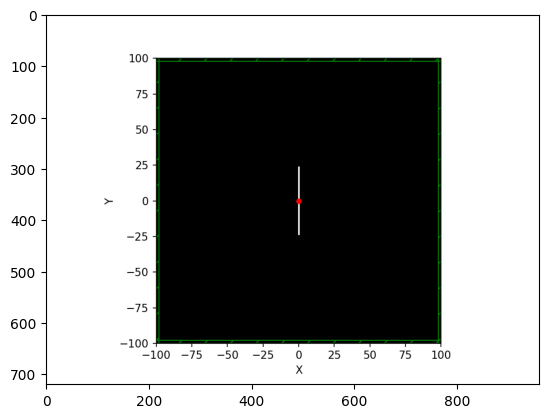

In [4]:

import matplotlib.pyplot as plt
img = plt.imread('sim.png')
plt.imshow(img)